# BEIP — EDA 01: Election Results Analysis

**Objective:** Explore the core election results from `silver.election_results` to understand:
- Historical candidate volume across election years
- Party dynamics (candidacy numbers, total wins, and party win rates)
- Vote share distributions for winners vs. non-winners
- Voter turnout patterns across Indian states
- Target variable distribution (`won`) and class imbalance

## 1. Setup and Data Loading

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

# Set style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.config import get_engine

engine = get_engine()
df = pd.read_sql("SELECT * FROM silver.election_results", engine)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")

Loaded 91,501 rows and 23 columns.


## 2. Basic Dataset Overview
Check data types, column null counts, and summary statistics.

In [2]:
df.head()

,year,state_name,constituency_name,constituency_no,constituency_type,candidate_name,sex,party,votes,vote_share,...,turnout_percentage,valid_votes,n_cand,margin,margin_percentage,candidate_type,incumbent,recontest,myneta_education,election_type
0,2019,Andaman & Nicobar Islands,Andaman & Nicobar Islands,1,GEN,Kuldeep Rai Sharma,M,INC,95308.0,45.98,...,65.09,207296,15,1407.0,0.68,GEN,False,True,Graduate Professional,Lok Sabha Election (GE)
1,2019,Andaman & Nicobar Islands,Andaman & Nicobar Islands,1,GEN,Vishal Jolly,M,BJP,93901.0,45.30,...,65.09,207296,15,88560.0,42.72,NaN,False,False,Graduate Professional,Lok Sabha Election (GE)
2,2019,Andaman & Nicobar Islands,Andaman & Nicobar Islands,1,GEN,Paritosh Kumar Haldar,M,IND,5341.0,2.58,...,65.09,207296,15,2502.0,1.21,NaN,False,False,Post Graduate,Lok Sabha Election (GE)
3,2019,Andaman & Nicobar Islands,Andaman & Nicobar Islands,1,GEN,Sanjay Meshack,M,AAAP,2839.0,1.37,...,65.09,207296,15,353.0,0.17,GEN,False,True,12th Pass,Lok Sabha Election (GE)
4,2019,Andaman & Nicobar Islands,Andaman & Nicobar Islands,1,GEN,Prakash Minj,M,BSP,2486.0,1.20,...,65.09,207296,15,765.0,0.37,NaN,False,False,Post Graduate,Lok Sabha Election (GE)


In [3]:
print("=== Column Data Types ===")
print(df.dtypes)

print("\n=== Missing Values Count ===")
print(df.isnull().sum())

=== Column Data Types ===
year                    int64
state_name                str
constituency_name         str
constituency_no         int64
constituency_type         str
candidate_name            str
sex                       str
party                     str
votes                 float64
vote_share            float64
position                int64
deposit_lost           object
electors              float64
turnout_percentage    float64
valid_votes             int64
n_cand                  int64
margin                float64
margin_percentage     float64
candidate_type            str
incumbent              object
recontest              object
myneta_education          str
election_type             str
dtype: object

=== Missing Values Count ===
year                      0
state_name                0
constituency_name         0
constituency_no           0
constituency_type         0
candidate_name            0
sex                    2175
party                    20
votes           

In [4]:
df.describe()

,year,constituency_no,votes,vote_share,position,electors,turnout_percentage,valid_votes,n_cand,margin,margin_percentage
count,91501.000000,91501.000000,9.149700e+04,91481.000000,91501.000000,9.148100e+04,91481.000000,9.150100e+04,91501.000000,91500.000000,91481.000000
mean,1996.553721,21.920536,5.258162e+04,9.038680,11.989967,1.126358e+06,60.595141,6.612785e+05,22.811193,25026.744721,4.232953
std,14.470549,18.846014,1.111000e+05,16.667014,28.465015,4.245387e+05,141.904409,2.907147e+05,47.972618,64241.401768,9.658908
min,1962.000000,1.000000,0.000000e+00,0.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,1.000000,0.000000,0.000000
25%,1989.000000,7.000000,1.004000e+03,0.150000,3.000000,8.400100e+05,49.970000,4.464150e+05,9.000000,40.000000,0.010000
50%,1996.000000,17.000000,3.314000e+03,0.520000,7.000000,1.103713e+06,58.190000,6.329700e+05,14.000000,410.000000,0.060000
75%,2009.000000,32.000000,2.840400e+04,6.200000,13.000000,1.409202e+06,66.430000,8.349570e+05,23.000000,8599.500000,1.690000
max,2021.000000,86.000000,1.068569e+06,97.690000,480.000000,3.623806e+06,15300.520000,1.763757e+06,480.000000,712215.000000,97.190000


## 3. Election Year Distribution
How many candidates ran across different election years?

,year,candidate_count
0,1962,1985
1,1963,10
2,1964,25
3,1965,18
4,1967,2388
5,1968,38
6,1969,27
7,1970,54
8,1971,2789
9,1972,53


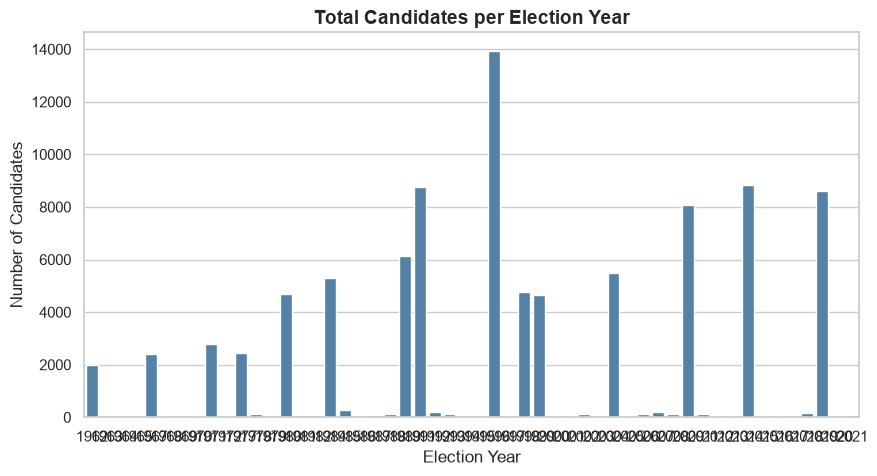

In [5]:
year_counts = df.groupby("year").size().reset_index(name="candidate_count")
display(year_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=year_counts, x="year", y="candidate_count", color="steelblue")
plt.title("Total Candidates per Election Year", fontsize=14, fontweight="bold")
plt.xlabel("Election Year")
plt.ylabel("Number of Candidates")
plt.show()

## 4. Party Performance and Win Rates
Evaluate party representation and calculate conversion rates (wins / contested seats).

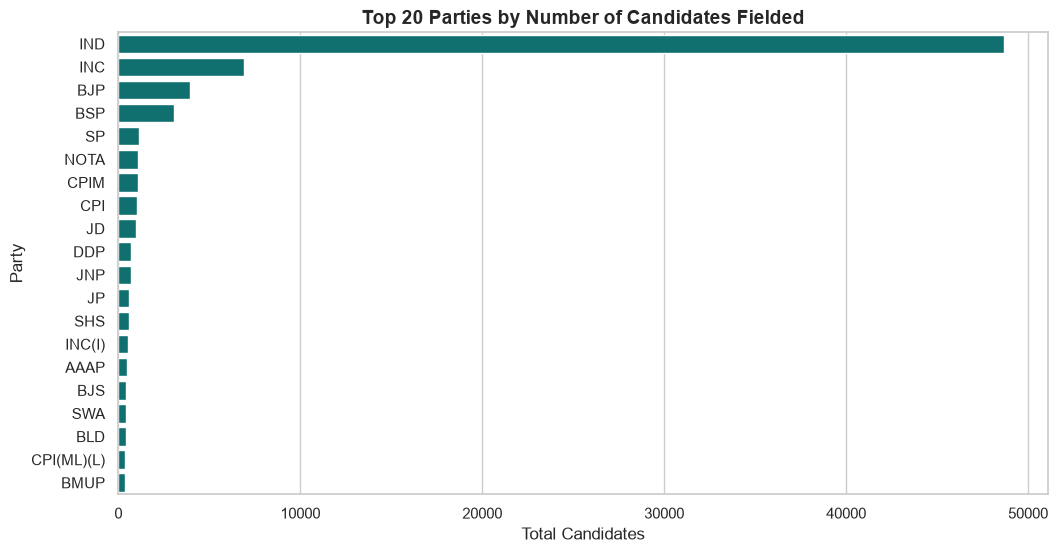

In [6]:
# Top 20 parties by candidates fielded
top_parties = df["party"].value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_parties.values, y=top_parties.index, color="teal")
plt.title("Top 20 Parties by Number of Candidates Fielded", fontsize=14, fontweight="bold")
plt.xlabel("Total Candidates")
plt.ylabel("Party")
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_22436\2224623076.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=major_party_stats, x="win_rate_pct", y="party", palette="viridis")


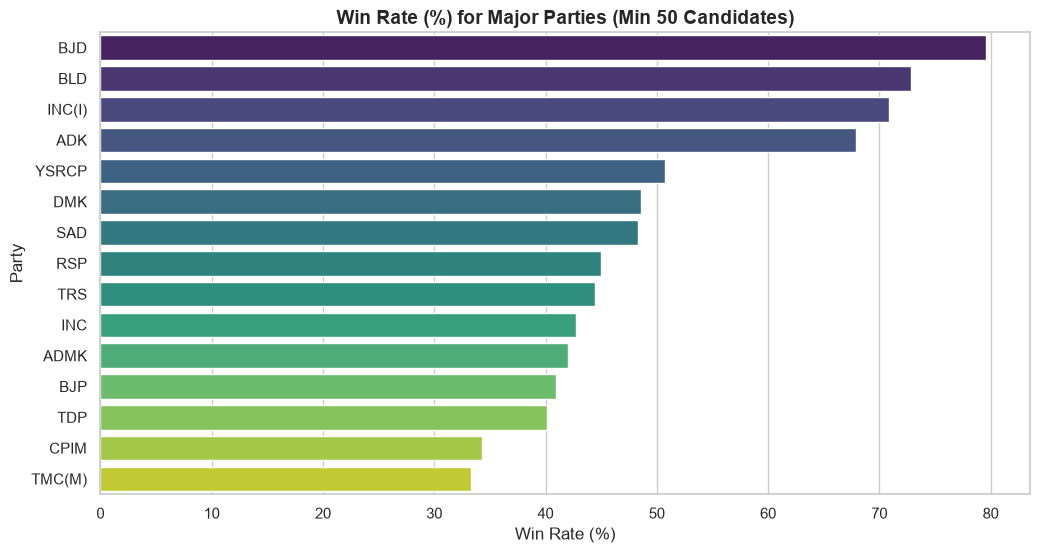

,party,total_candidates,total_wins,avg_vote_share,win_rate_pct
271,BJD,98,78,47.393878,79.591837
304,BLD,405,295,56.064000,72.839506
610,INC(I),518,367,46.313745,70.849421
68,ADK,81,55,53.933457,67.901235
1571,YSRCP,67,34,38.984328,50.746269
474,DMK,350,170,43.537086,48.571429
1314,SAD,118,57,39.586017,48.305085
1262,RSP,100,45,28.533232,45.000000
1491,TRS,72,32,29.362083,44.444444
609,INC,6884,2941,37.416356,42.722255


In [7]:
# Calculate Win Rates for top parties with at least 50 candidates
party_stats = df.groupby("party").agg(
    total_candidates=("candidate_name", "count"),
    total_wins=("position", lambda p: (p == 1).sum()),
    avg_vote_share=("vote_share", "mean")
).reset_index()

party_stats["win_rate_pct"] = (party_stats["total_wins"] / party_stats["total_candidates"]) * 100

# Filter to parties with substantial candidacy to avoid outlier 100% win-rates (e.g. min 50 candidates)
major_party_stats = party_stats[party_stats["total_candidates"] >= 50].sort_values("win_rate_pct", ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=major_party_stats, x="win_rate_pct", y="party", palette="viridis")
plt.title("Win Rate (%) for Major Parties (Min 50 Candidates)", fontsize=14, fontweight="bold")
plt.xlabel("Win Rate (%)")
plt.ylabel("Party")
plt.show()

display(major_party_stats)

## 5. Vote Share Distribution
Compare vote share distributions for winners (position = 1) versus non-winners.

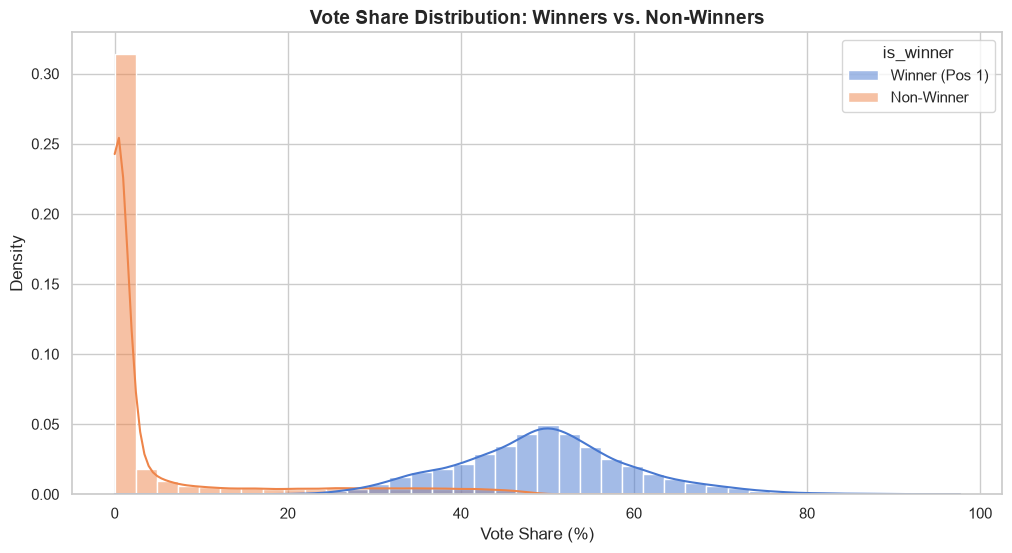

=== Vote Share Summary for Winners ===
count    8271.000000
mean       49.762596
std        10.159936
min        16.710000
25%        43.265000
50%        49.710000
75%        55.655000
max        97.690000
Name: vote_share, dtype: float64


In [8]:
df["is_winner"] = df["position"].apply(lambda p: "Winner (Pos 1)" if p == 1 else "Non-Winner")

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="vote_share", hue="is_winner", bins=40, kde=True, stat="density", common_norm=False)
plt.title("Vote Share Distribution: Winners vs. Non-Winners", fontsize=14, fontweight="bold")
plt.xlabel("Vote Share (%)")
plt.ylabel("Density")
plt.show()

# Summary statistics for winners
winner_summary = df[df["position"] == 1]["vote_share"].describe()
print("=== Vote Share Summary for Winners ===")
print(winner_summary)

## 6. Voter Turnout by State
Analyze which states consistently record high vs. low voter turnout.

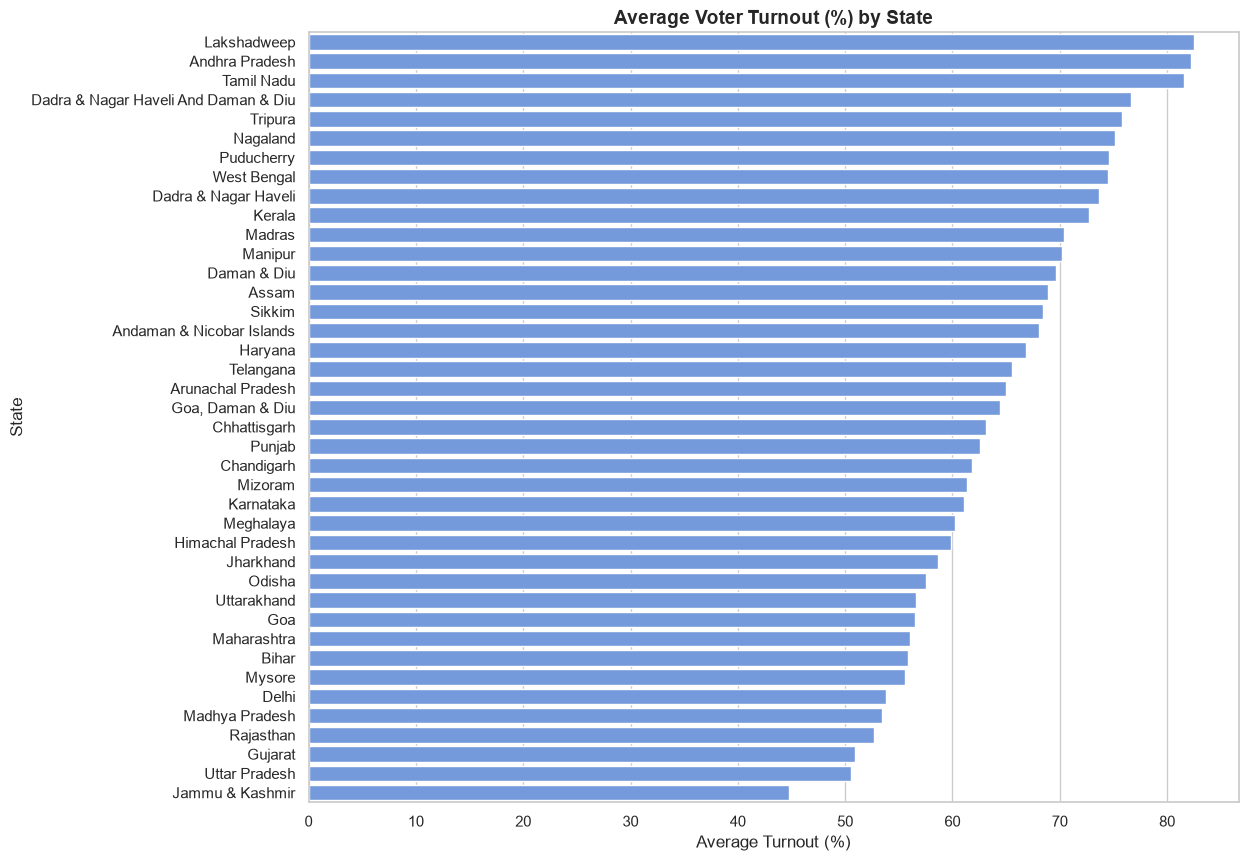

In [9]:
state_turnout = df.groupby("state_name")["turnout_percentage"].mean().reset_index()
state_turnout = state_turnout.dropna().sort_values("turnout_percentage", ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(data=state_turnout, x="turnout_percentage", y="state_name", color="cornflowerblue")
plt.title("Average Voter Turnout (%) by State", fontsize=14, fontweight="bold")
plt.xlabel("Average Turnout (%)")
plt.ylabel("State")
plt.show()

## 7. Target Variable & Class Imbalance
Define the machine learning target `won` and examine the class balance ratio.

=== Target Variable Counts (won) ===
Lost (0): 83,211 (90.94%)
Won  (1): 8,290 (9.06%)
Imbalance Ratio: ~10:1


C:\Users\chris\AppData\Local\Temp\ipykernel_22436\3260173068.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="won", palette=["#e74c3c", "#2ecc71"])


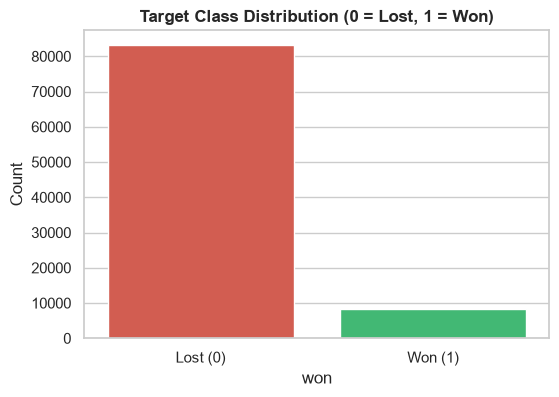

In [10]:
df["won"] = (df["position"] == 1).astype(int)
won_counts = df["won"].value_counts()

print("=== Target Variable Counts (won) ===")
print(f"Lost (0): {won_counts.get(0, 0):,} ({won_counts.get(0, 0)/len(df)*100:.2f}%)")
print(f"Won  (1): {won_counts.get(1, 0):,} ({won_counts.get(1, 0)/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: ~{won_counts.get(0, 0) // max(1, won_counts.get(1, 0))}:1")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="won", palette=["#e74c3c", "#2ecc71"])
plt.title("Target Class Distribution (0 = Lost, 1 = Won)", fontsize=12, fontweight="bold")
plt.xticks([0, 1], ["Lost (0)", "Won (1)"])
plt.ylabel("Count")
plt.show()